In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import pickle 

In [2]:
##Load the cleaned dataset
df = pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'Algerian_forest_fires_cleaned_dataset.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [ ]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [ ]:
print(df['year'].nunique())
print(df['month'].nunique())
print(df['day'].nunique())

1
4
31


In [ ]:
df = df.drop(['day','month','year'], axis = 1)

In [ ]:
df['Classes'].unique()

array(['not fire   ', 'fire   ', 'fire', 'fire ', 'not fire', 'not fire ',
       'not fire     ', 'not fire    '], dtype=object)

In [ ]:
df['Classes'] = df['Classes'].str.strip()
df['Classes'] = np.where(df['Classes'].str.contains('not fire'),0,1)


In [ ]:
df['Classes'].unique()

array([0, 1])

In [ ]:
x=df.drop('FWI', axis = 1)
y=df['FWI']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((182, 11), (61, 11), (182,), (61,))

In [ ]:
x_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [ ]:
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


In [ ]:
corr_matrix = x_train.corr()

corr_matrix

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


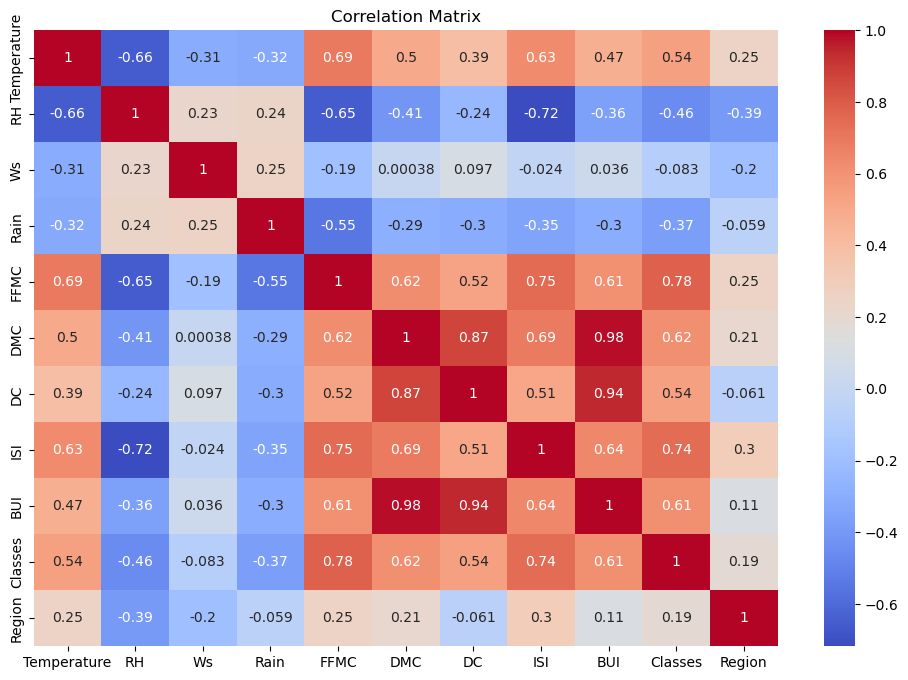

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
def correlation(data , threshold):
    col_corr = set() 
    corr_matrix = data.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [ ]:
corr_features = correlation(x_train, 0.85)

corr_features

{'BUI', 'DC'}

In [ ]:
print("Number of correlated features:", len(corr_features))
print(corr_features)

Number of correlated features: 2
{'DC', 'BUI'}


In [ ]:
x_train = x_train.drop(corr_features, axis = 1)
x_test = x_test.drop(corr_features, axis = 1)

In [ ]:
x_train.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI', 'Classes',
       'Region'],
      dtype='object')

In [ ]:
Scaler = StandardScaler()
x_train_scaled = Scaler.fit_transform(x_train)
x_test_scaled = Scaler.transform(x_test)


Text(0.5, 1.0, 'X_train After Scaling')

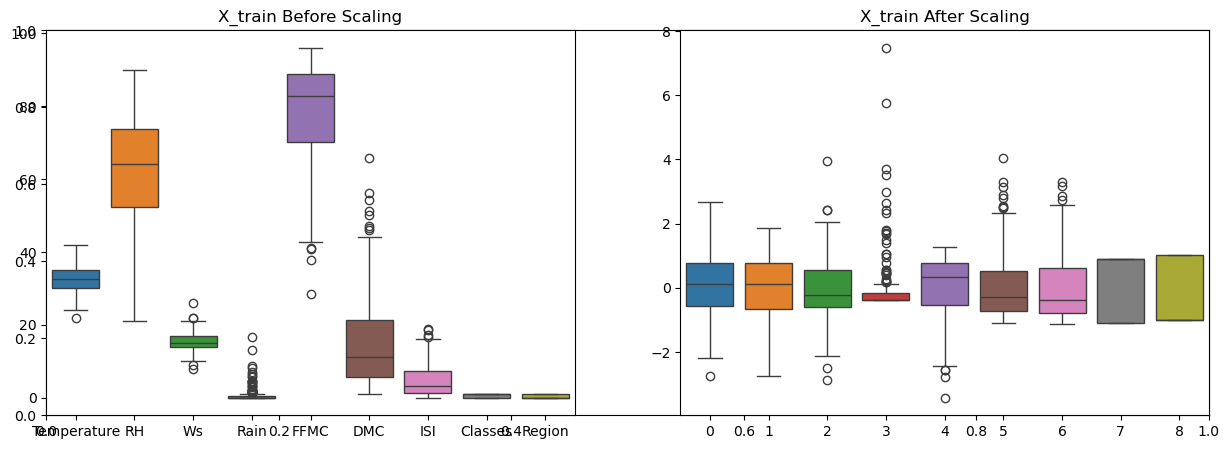

In [ ]:
plt.subplots(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=x_train)
plt.title('X_train Before Scaling')

plt.subplot(1, 2, 2)
sns.boxplot(data=x_train_scaled)
plt.title('X_train After Scaling')

In [ ]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Mean Absolute Error: 0.5468236465249979
R-squared: 0.9847657384266952


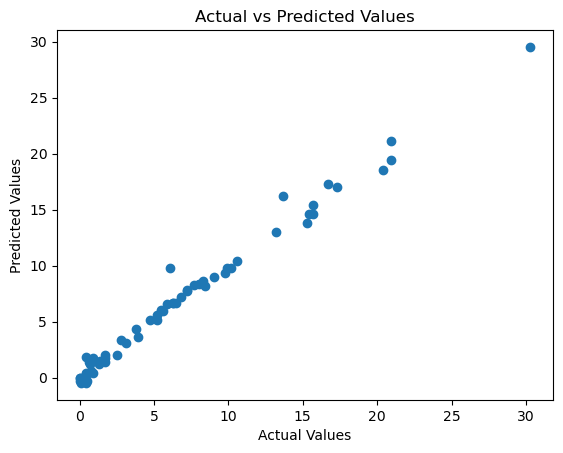

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

Best alpha for Ridge Regression: 1.0
Mean Absolute Error (Ridge Regression): 0.564230534010569
R-squared (Ridge Regression): 0.9842993364555513


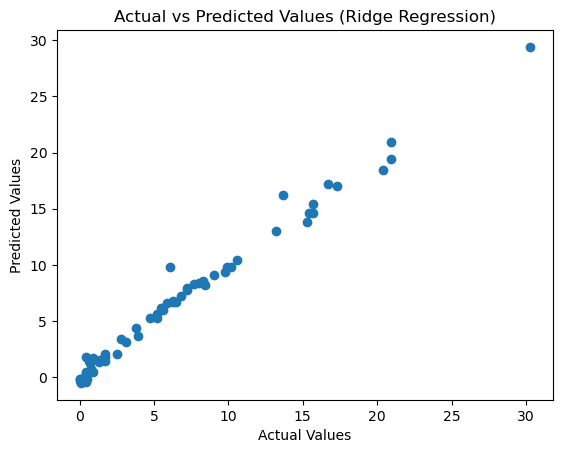

In [ ]:
ridgecv = RidgeCV(alphas=np.logspace(-6, 6, 13), cv=5)
ridgecv.fit(x_train_scaled, y_train)
print("Best alpha for Ridge Regression:", ridgecv.alpha_)

mae_ridge = mean_absolute_error(y_test, ridgecv.predict(x_test_scaled))
r2_ridge = r2_score(y_test, ridgecv.predict(x_test_scaled))
print("Mean Absolute Error (Ridge Regression):", mae_ridge)
print("R-squared (Ridge Regression):", r2_ridge)


plt.scatter(y_test, ridgecv.predict(x_test_scaled))
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Ridge Regression)")
plt.show()


Best alpha for Lasso Regression: 0.1
Mean Absolute Error (Lasso): 0.7084773819658268
R-squared (Lasso): 0.9783246631008717


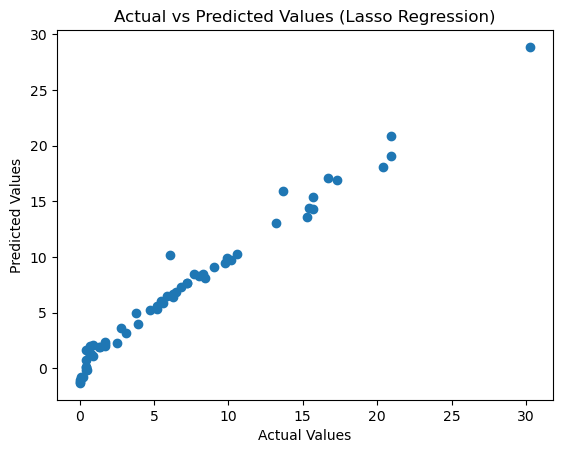

In [ ]:
lassocv = LassoCV(alphas=np.logspace(-6, 6, 13), cv=5)
lassocv.fit(x_train_scaled, y_train)
print("Best alpha for Lasso Regression:", lassocv.alpha_)

mae_lasso = mean_absolute_error(y_test, lassocv.predict(x_test_scaled))
r2_lasso = r2_score(y_test, lassocv.predict(x_test_scaled))
print("Mean Absolute Error (Lasso):", mae_lasso)
print("R-squared (Lasso):", r2_lasso)


plt.scatter(y_test, lassocv.predict(x_test_scaled))
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Lasso Regression)")
plt.show()

Best alpha for Elastic Net Regression: 0.01
Best l1_ratio for Elastic Net Regression: 0.1
Mean Absolute Error (Elastic Net): 0.5782161632865679
R-squared (Elastic Net): 0.983920100527251


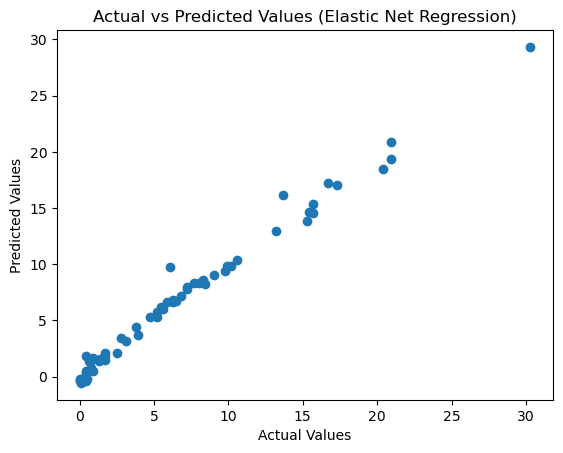

In [ ]:
elasticcv = ElasticNetCV(alphas=np.logspace(-6, 6, 13), l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5)
elasticcv.fit(x_train_scaled, y_train)
print("Best alpha for Elastic Net Regression:", elasticcv.alpha_)
print("Best l1_ratio for Elastic Net Regression:", elasticcv.l1_ratio_)


mae_elastic = mean_absolute_error(y_test, elasticcv.predict(x_test_scaled))
r2_elastic = r2_score(y_test, elasticcv.predict(x_test_scaled))
print("Mean Absolute Error (Elastic Net):", mae_elastic)
print("R-squared (Elastic Net):", r2_elastic)

plt.scatter(y_test, elasticcv.predict(x_test_scaled))
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Elastic Net Regression)")
plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'RidgeCV',
        'LassoCV',
        'ElasticNetCV'
    ],

    'MAE': [
        mae,
        mae_ridge,
        mae_lasso,
        mae_elastic
    ],

    'R2 Score': [
        r2,
        r2_ridge,
        r2_lasso,
        r2_elastic
    ]
})

results = results.sort_values(
    by='R2 Score',
    ascending=False
)

results

,Model,MAE,R2 Score
0,Linear Regression,0.546824,0.984766
1,RidgeCV,0.564231,0.984299
3,ElasticNetCV,0.578216,0.983920
2,LassoCV,0.708477,0.978325


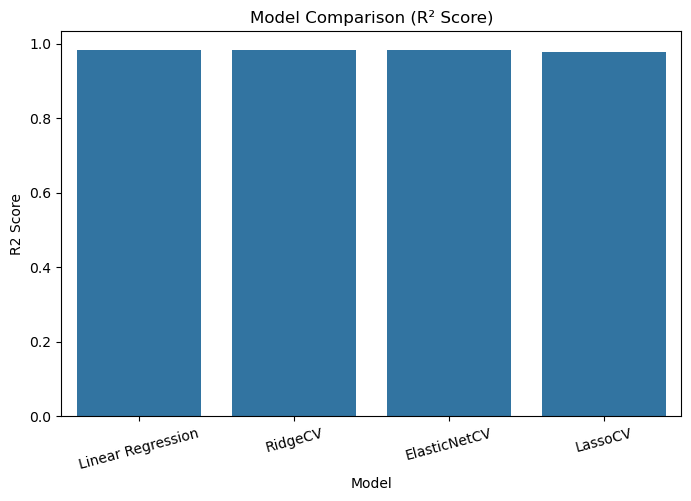

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title('Model Comparison (R² Score)')
plt.xticks(rotation=15)

plt.show()

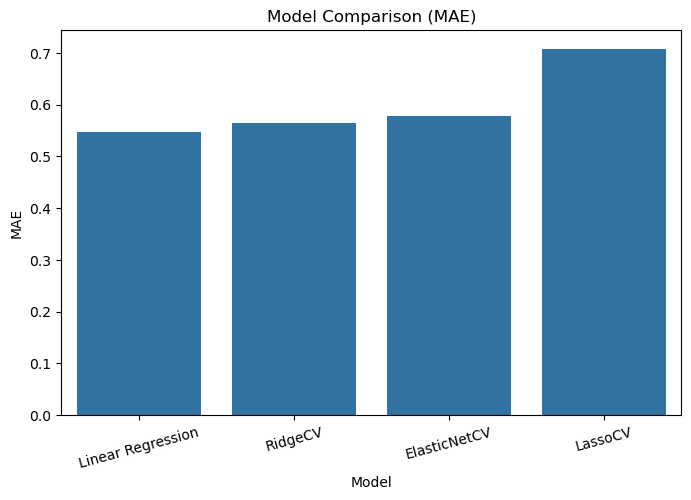

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='MAE'
)

plt.title('Model Comparison (MAE)')
plt.xticks(rotation=15)

plt.show()

In [ ]:
pickle.dump(model, open('Algerian_forest_fires_model.pkl', 'wb'))
pickle.dump(Scaler, open('Algerian_forest_fires_scaler.pkl', 'wb'))


In [ ]:
#import os

#print(os.listdir())

In [ ]:
loaded_model = pickle.load(open('Algerian_forest_fires_model.pkl', 'rb'))

loaded_scaler = pickle.load(open('Algerian_forest_fires_scaler.pkl', 'rb'))



Conclusion

Four regression models were evaluated:

• Linear Regression
• RidgeCV
• LassoCV
• ElasticNetCV

Linear Regression achieved the best performance with:

MAE = 0.5468
R² Score = 0.9848

Correlation analysis showed no severe multicollinearity among predictors. Therefore, all features were retained.

The trained model and scaler were serialized using Pickle for future deployment.